In [1]:
!pip uninstall -y albumentations albucore qudida

!rm -rf /usr/local/lib/python3.12/dist-packages/albumentations
!rm -rf /usr/local/lib/python3.12/dist-packages/albumentations-*
!rm -rf /usr/local/lib/python3.12/dist-packages/albucore
!rm -rf /usr/local/lib/python3.12/dist-packages/albucore-*
!rm -rf /usr/local/lib/python3.12/dist-packages/qudida
!rm -rf /usr/local/lib/python3.12/dist-packages/qudida-*

!pip install -q --no-cache-dir albumentations==1.4.0

Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
Found existing installation: albucore 0.0.24
Uninstalling albucore-0.0.24:
  Successfully uninstalled albucore-0.0.24
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 9.6 MB/s eta 0:00:00


In [2]:
import os
import random
import glob
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torchvision
from torchvision.models import resnet18, ResNet18_Weights

In [3]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("Albumentations version:", A.__version__)

Albumentations version: 1.4.0


In [4]:
class CFG:
    seed = 42
    image_size = 352
    batch_size = 8
    num_workers = 0
    epochs = 30
    lr = 1e-4
    min_lr = 1e-6
    weight_decay = 1e-4
    device = "cuda" if torch.cuda.is_available() else "cpu"
    use_amp = True
    save_dir = "/kaggle/working/cod_project_outputs"
    patience = 8
    
os.makedirs(CFG.save_dir, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG.seed)

print("Device:", CFG.device)

Device: cuda


In [5]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

print("Kaggle input datasets:")
for p in INPUT_ROOT.glob("*"):
    print(p)

Kaggle input datasets:
/kaggle/input/datasets


In [6]:
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/melikesoygullucu/")

CAMO_ROOT = DATA_ROOT / "camo-v1/CAMO-V.1.0-CVIU2019"
COD10K_ROOT = DATA_ROOT / "cod10k/COD10K-v3"

print("CAMO exists:", CAMO_ROOT.exists(), CAMO_ROOT)
print("COD10K exists:", COD10K_ROOT.exists(), COD10K_ROOT)

CAMO exists: True /kaggle/input/datasets/melikesoygullucu/camo-v1/CAMO-V.1.0-CVIU2019
COD10K exists: True /kaggle/input/datasets/melikesoygullucu/cod10k/COD10K-v3


In [7]:
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp"]

def list_images(folder):
    folder = Path(folder)
    files = []
    for ext in IMG_EXTS:
        files.extend(folder.rglob(f"*{ext}"))
        files.extend(folder.rglob(f"*{ext.upper()}"))
    return sorted(files)


def find_matching_mask(image_path, mask_folder):
    image_path = Path(image_path)
    mask_folder = Path(mask_folder)

    stem = image_path.stem

    for ext in IMG_EXTS:
        candidate = mask_folder / f"{stem}{ext}"
        if candidate.exists():
            return candidate

        candidate_upper = mask_folder / f"{stem}{ext.upper()}"
        if candidate_upper.exists():
            return candidate_upper

    for m in list_images(mask_folder):
        if m.stem == stem:
            return m

    return None


def build_camo_pairs(camo_root, split="Train"):
    camo_root = Path(camo_root)

    image_dir = camo_root / "Images" / split
    mask_dir = camo_root / "GT"

    image_files = list_images(image_dir)

    pairs = []
    missing = []

    for img in image_files:
        mask = find_matching_mask(img, mask_dir)
        if mask is not None:
            pairs.append((img, mask))
        else:
            missing.append(img)

    print(f"CAMO {split}: images={len(image_files)}, pairs={len(pairs)}, missing={len(missing)}")

    if len(missing) > 0:
        print("Example missing CAMO masks:")
        for m in missing[:5]:
            print(m)

    return pairs


def build_cod10k_pairs(cod10k_root, split="Train", include_noncam=False):
    cod10k_root = Path(cod10k_root)

    image_dir = cod10k_root / split / "Image"
    mask_dir = cod10k_root / split / "GT_Object"

    image_files = list_images(image_dir)

    pairs = []
    missing = []
    skipped_noncam = 0

    for img in image_files:
        # NonCAM görüntüleri çıkar
        if (not include_noncam) and ("NonCAM" in img.name):
            skipped_noncam += 1
            continue

        mask = find_matching_mask(img, mask_dir)

        if mask is not None:
            pairs.append((img, mask))
        else:
            missing.append(img)

    print(
        f"COD10K {split}: images={len(image_files)}, "
        f"pairs={len(pairs)}, missing={len(missing)}, skipped_noncam={skipped_noncam}"
    )

    if len(missing) > 0:
        print("Example missing COD10K masks:")
        for m in missing[:5]:
            print(m)

    return pairs

In [8]:
camo_train_pairs = build_camo_pairs(CAMO_ROOT, split="Train")
camo_test_pairs  = build_camo_pairs(CAMO_ROOT, split="Test")

cod10k_train_pairs = build_cod10k_pairs(COD10K_ROOT, split="Train", include_noncam=False)
cod10k_test_pairs  = build_cod10k_pairs(COD10K_ROOT, split="Test", include_noncam=False)

print()
print("CAMO train:", len(camo_train_pairs))
print("CAMO test :", len(camo_test_pairs))
print("COD10K train:", len(cod10k_train_pairs))
print("COD10K test :", len(cod10k_test_pairs))

CAMO Train: images=1000, pairs=1000, missing=0
CAMO Test: images=250, pairs=250, missing=0
COD10K Train: images=6000, pairs=3040, missing=0, skipped_noncam=2960
COD10K Test: images=4000, pairs=2026, missing=0, skipped_noncam=1974

CAMO train: 1000
CAMO test : 250
COD10K train: 3040
COD10K test : 2026


In [9]:
import random

random.seed(CFG.seed)

train_pairs = camo_train_pairs + cod10k_train_pairs
val_pairs = camo_test_pairs
test_pairs = cod10k_test_pairs

random.shuffle(train_pairs)

print("Train pairs:", len(train_pairs))
print("Val pairs  :", len(val_pairs))
print("Test pairs :", len(test_pairs))

Train pairs: 4040
Val pairs  : 250
Test pairs : 2026


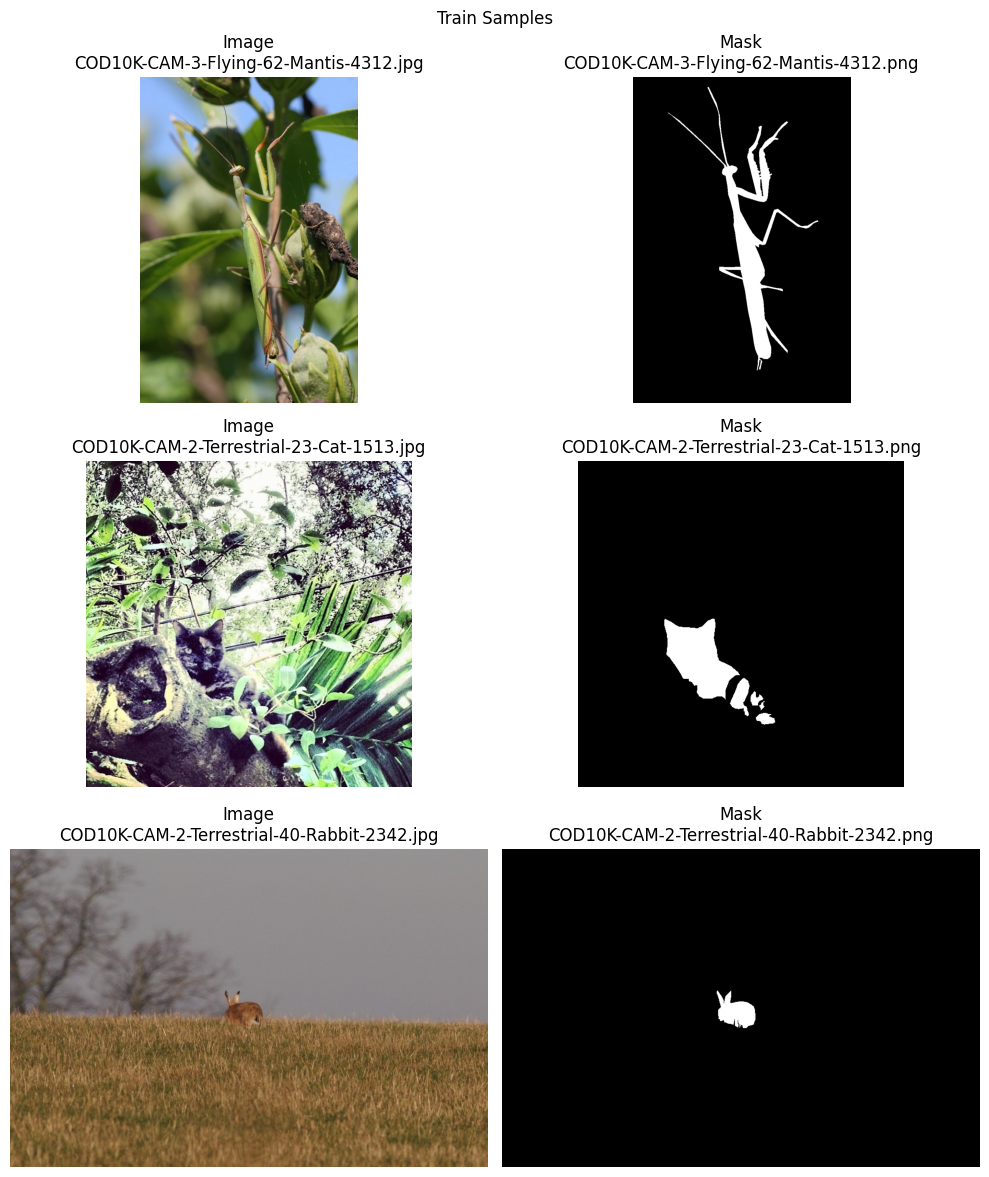

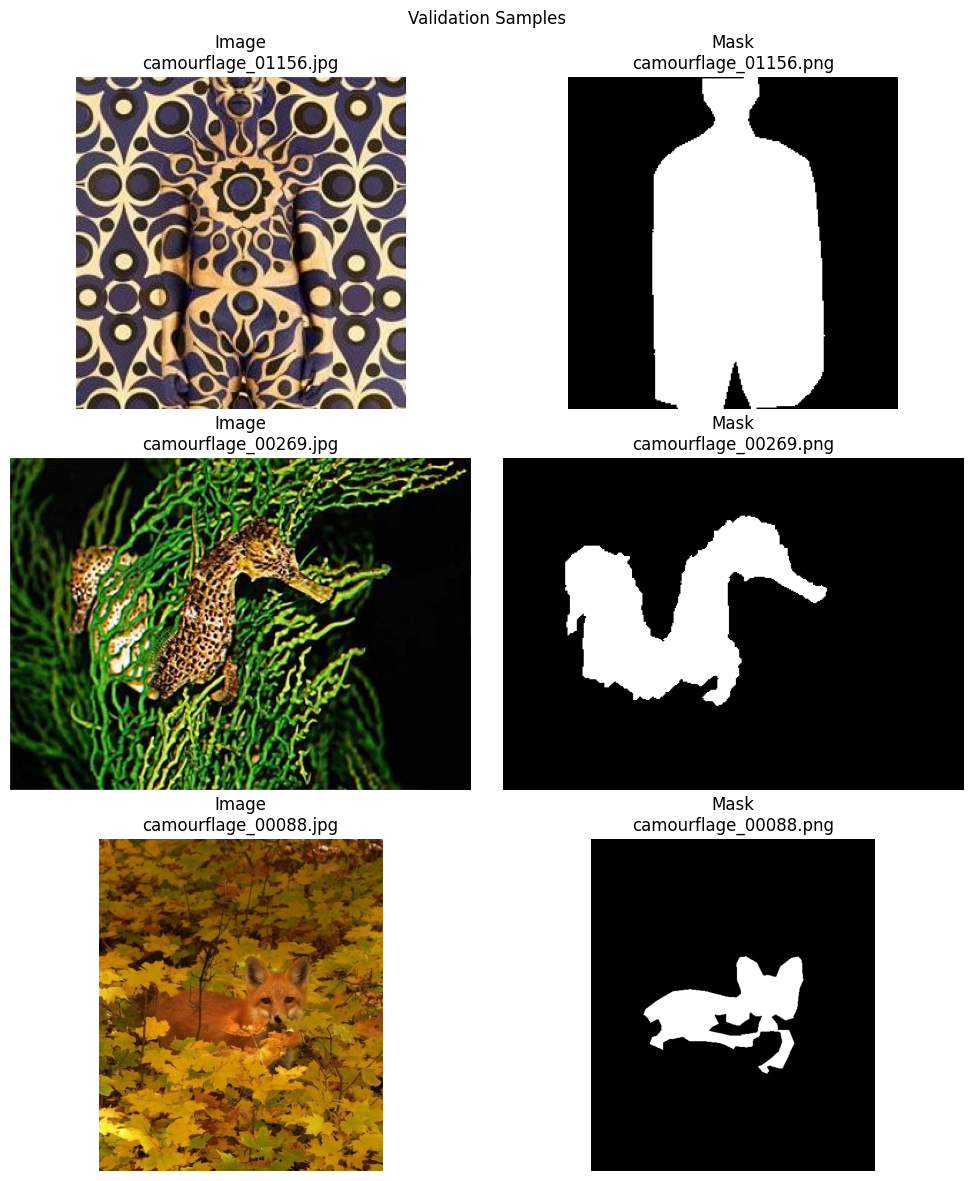

In [10]:
import matplotlib.pyplot as plt
import cv2
import random

def read_rgb(path):
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Image could not be read: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def read_mask(path):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Mask could not be read: {path}")
    return mask

def show_pairs(pairs, title="Dataset samples", n=3):
    sample_pairs = random.sample(pairs, min(n, len(pairs)))
    
    plt.figure(figsize=(10, 4 * len(sample_pairs)))
    
    for i, (img_path, mask_path) in enumerate(sample_pairs):
        img = read_rgb(img_path)
        mask = read_mask(mask_path)

        plt.subplot(len(sample_pairs), 2, 2*i + 1)
        plt.imshow(img)
        plt.title(f"Image\n{img_path.name}")
        plt.axis("off")

        plt.subplot(len(sample_pairs), 2, 2*i + 2)
        plt.imshow(mask, cmap="gray")
        plt.title(f"Mask\n{mask_path.name}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_pairs(train_pairs, title="Train Samples", n=3)
show_pairs(val_pairs, title="Validation Samples", n=3)

In [11]:
def create_frequency_map(image_rgb):
    """
    FFT-based high-frequency map.
    
    image_rgb: H x W x 3, uint8
    output: H x W, float32 [0, 1]
    """
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    gray = gray.astype(np.float32) / 255.0
    
    fft = np.fft.fft2(gray)
    fft_shift = np.fft.fftshift(fft)
    
    h, w = gray.shape
    center_h, center_w = h // 2, w // 2
    
    radius = min(h, w) // 8
    mask = np.ones((h, w), np.float32)
    cv2.circle(mask, (center_w, center_h), radius, 0, -1)
    
    high_freq = fft_shift * mask
    img_back = np.fft.ifft2(np.fft.ifftshift(high_freq))
    img_back = np.abs(img_back)
    
    img_back = (img_back - img_back.min()) / (img_back.max() - img_back.min() + 1e-8)
    return img_back.astype(np.float32)

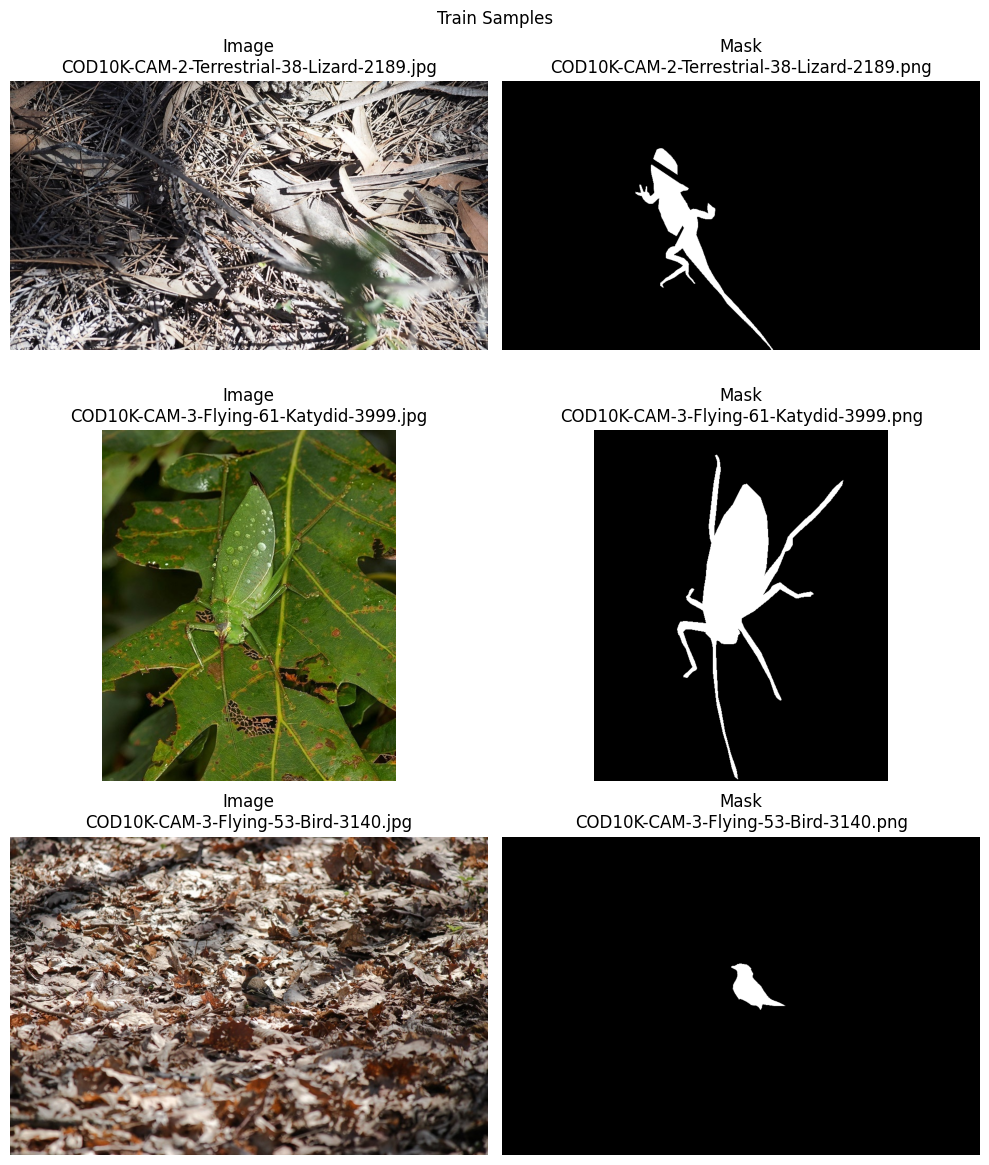

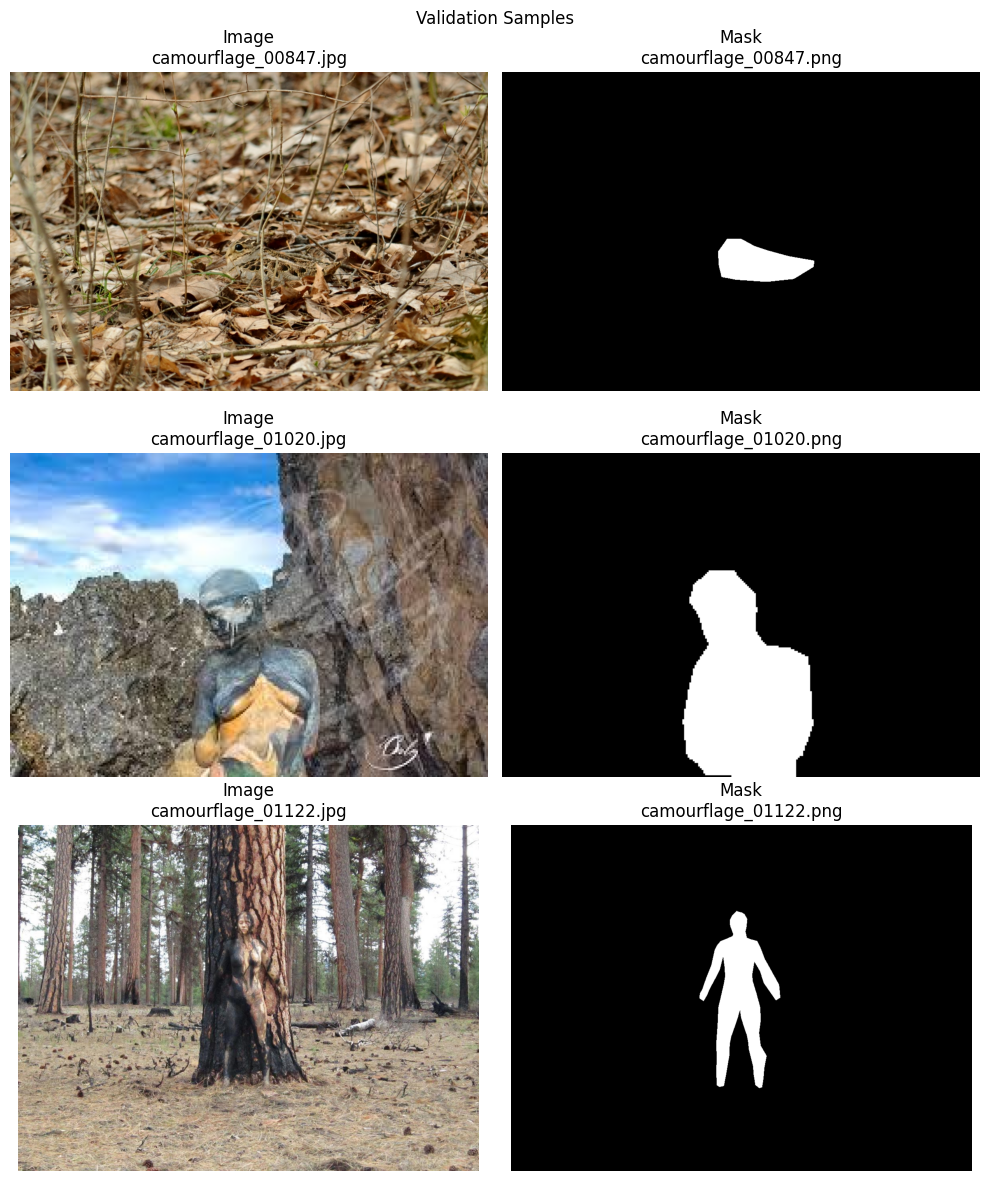

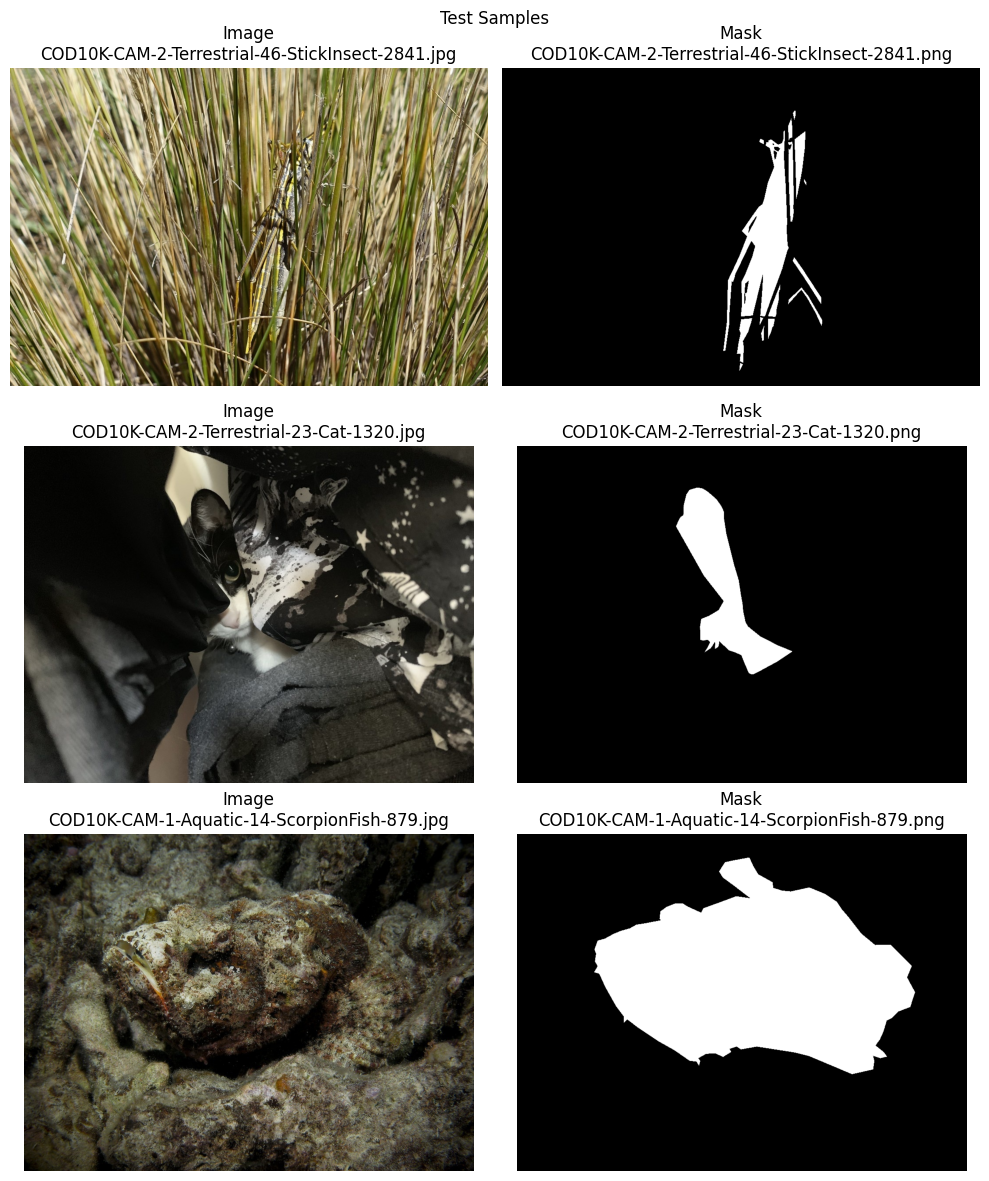

In [12]:
show_pairs(train_pairs, title="Train Samples", n=3)
show_pairs(val_pairs, title="Validation Samples", n=3)
show_pairs(test_pairs, title="Test Samples", n=3)

In [13]:
train_tfms = A.Compose([
    A.Resize(CFG.image_size, CFG.image_size),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.15,
        rotate_limit=20,
        border_mode=cv2.BORDER_REFLECT_101,
        value=0,
        mask_value=0,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.4
    ),

    A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
    A.MotionBlur(blur_limit=3, p=0.15),

    A.Normalize(
        mean=(0.485, 0.456, 0.406, 0.0),
        std=(0.229, 0.224, 0.225, 1.0)
    ),
    ToTensorV2()
])


val_tfms = A.Compose([
    A.Resize(CFG.image_size, CFG.image_size),
    A.Normalize(
        mean=(0.485, 0.456, 0.406, 0.0),
        std=(0.229, 0.224, 0.225, 1.0)
    ),
    ToTensorV2()
])


class CODDataset(Dataset):
    def __init__(self, pairs, transforms=None, use_frequency=True):
        self.pairs = pairs
        self.transforms = transforms
        self.use_frequency = use_frequency

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        
        image = read_rgb(img_path)
        mask = read_mask(mask_path)

        mask = (mask > 127).astype(np.float32)
        
        if self.use_frequency:
            freq = create_frequency_map(image)
            freq_uint8 = (freq * 255).astype(np.uint8)
            image_4ch = np.dstack([image, freq_uint8])
        else:
            zero_freq = np.zeros(image.shape[:2], dtype=np.uint8)
            image_4ch = np.dstack([image, zero_freq])
        
        if self.transforms:
            augmented = self.transforms(image=image_4ch, mask=mask)
            image_4ch = augmented["image"]
            mask = augmented["mask"].unsqueeze(0).float()
        
        return image_4ch.float(), mask

In [14]:
train_ds = CODDataset(train_pairs, transforms=train_tfms, use_frequency=True)
val_ds = CODDataset(val_pairs, transforms=val_tfms, use_frequency=True)
test_ds = CODDataset(test_pairs, transforms=val_tfms, use_frequency=True)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True
)

images, masks = next(iter(train_loader))
print("Image batch:", images.shape)
print("Mask batch :", masks.shape)

Image batch: torch.Size([8, 4, 352, 352])
Mask batch : torch.Size([8, 1, 352, 352])


In [15]:
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch + skip_ch, out_ch, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)

    def forward(self, x, skip=None):
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        if skip is not None:
            x = torch.cat([x, skip], dim=1)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return x


class ResNet18UNetFreq(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        
        weights = ResNet18_Weights.DEFAULT
        encoder = resnet18(weights=weights)
        
        old_conv = encoder.conv1
        encoder.conv1 = nn.Conv2d(
            in_channels,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )
        
        with torch.no_grad():
            encoder.conv1.weight[:, :3] = old_conv.weight
            encoder.conv1.weight[:, 3:4] = old_conv.weight.mean(dim=1, keepdim=True)
        
        self.conv1 = encoder.conv1
        self.bn1 = encoder.bn1
        self.relu = encoder.relu
        self.maxpool = encoder.maxpool
        
        self.layer1 = encoder.layer1   # 64
        self.layer2 = encoder.layer2   # 128
        self.layer3 = encoder.layer3   # 256
        self.layer4 = encoder.layer4   # 512
        
        self.dec4 = DecoderBlock(512, 256, 256)
        self.dec3 = DecoderBlock(256, 128, 128)
        self.dec2 = DecoderBlock(128, 64, 64)
        self.dec1 = DecoderBlock(64, 64, 32)
        
        self.final = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))     # 176x176
        x1 = self.maxpool(x0)                       # 88x88
        
        e1 = self.layer1(x1)                        # 88x88
        e2 = self.layer2(e1)                        # 44x44
        e3 = self.layer3(e2)                        # 22x22
        e4 = self.layer4(e3)                        # 11x11
        
        d4 = self.dec4(e4, e3)                      # 22x22
        d3 = self.dec3(d4, e2)                      # 44x44
        d2 = self.dec2(d3, e1)                      # 88x88
        d1 = self.dec1(d2, x0)                      # 176x176
        
        out = F.interpolate(d1, size=(CFG.image_size, CFG.image_size), mode="bilinear", align_corners=False)
        out = self.final(out)
        
        return out

In [16]:
def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)

    dice = (2 * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()


def focal_loss_with_logits(logits, targets, alpha=0.35, gamma=2.0):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    probs = torch.sigmoid(logits)

    pt = probs * targets + (1 - probs) * (1 - targets)
    focal_weight = (1 - pt) ** gamma

    alpha_weight = alpha * targets + (1 - alpha) * (1 - targets)

    loss = alpha_weight * focal_weight * bce
    return loss.mean()


def total_loss_fn(logits, targets):
    focal = focal_loss_with_logits(logits, targets, alpha=0.35, gamma=2.0)
    dsc = dice_loss(logits, targets)

    total = focal + dsc

    return total, {
        "focal_loss": focal.item(),
        "dice_loss": dsc.item()
    }

In [17]:
@torch.no_grad()
def compute_metrics(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    targets = targets.float()

    tp = (preds * targets).sum(dim=(1, 2, 3))
    fp = (preds * (1 - targets)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * targets).sum(dim=(1, 2, 3))

    dice = (2 * tp + 1e-6) / (2 * tp + fp + fn + 1e-6)
    iou = (tp + 1e-6) / (tp + fp + fn + 1e-6)
    mae = torch.abs(probs - targets).mean(dim=(1, 2, 3))

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "mae": mae.mean().item()
    }

In [18]:
def train_one_epoch(model, loader, optimizer, scaler, epoch):
    model.train()
    
    total_loss = 0
    total_dice = 0
    total_iou = 0
    total_mae = 0
    
    pbar = tqdm(loader, desc=f"Train Epoch {epoch}")
    
    for images, masks in pbar:
        images = images.to(CFG.device)
        masks = masks.to(CFG.device)
        
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast(enabled=CFG.use_amp):
            logits = model(images)
            loss, loss_parts = total_loss_fn(logits, masks)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        metrics = compute_metrics(logits.detach(), masks)
        
        total_loss += loss.item()
        total_dice += metrics["dice"]
        total_iou += metrics["iou"]
        total_mae += metrics["mae"]
        
        pbar.set_postfix({
            "loss": loss.item(),
            "dice": metrics["dice"],
            "iou": metrics["iou"],
            "mae": metrics["mae"]
        })
    
    n = len(loader)
    return {
        "loss": total_loss / n,
        "dice": total_dice / n,
        "iou": total_iou / n,
        "mae": total_mae / n
    }


@torch.no_grad()
def validate_one_epoch(model, loader, epoch):
    model.eval()
    
    total_loss = 0
    total_dice = 0
    total_iou = 0
    total_mae = 0
    
    pbar = tqdm(loader, desc=f"Val Epoch {epoch}")
    
    for images, masks in pbar:
        images = images.to(CFG.device)
        masks = masks.to(CFG.device)
        
        logits = model(images)
        loss, loss_parts = total_loss_fn(logits, masks)
        metrics = compute_metrics(logits, masks)
        
        total_loss += loss.item()
        total_dice += metrics["dice"]
        total_iou += metrics["iou"]
        total_mae += metrics["mae"]
        
        pbar.set_postfix({
            "loss": loss.item(),
            "dice": metrics["dice"],
            "iou": metrics["iou"],
            "mae": metrics["mae"]
        })
    
    n = len(loader)
    return {
        "loss": total_loss / n,
        "dice": total_dice / n,
        "iou": total_iou / n,
        "mae": total_mae / n
    }

In [19]:
model = ResNet18UNetFreq(in_channels=4).to(CFG.device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=CFG.min_lr
)

scaler = torch.cuda.amp.GradScaler(enabled=CFG.use_amp)

history = []

best_val_dice = -1
best_model_path = os.path.join(
    CFG.save_dir,
    "best_resnet18_fft_freq_focal_dice_352_plateau.pth"
)

patience_counter = 0

for epoch in range(1, CFG.epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, scaler, epoch)
    val_metrics = validate_one_epoch(model, val_loader, epoch)

    scheduler.step(val_metrics["loss"])

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "train_mae": train_metrics["mae"],
        "val_loss": val_metrics["loss"],
        "val_dice": val_metrics["dice"],
        "val_iou": val_metrics["iou"],
        "val_mae": val_metrics["mae"],
        "lr": optimizer.param_groups[0]["lr"]
    }

    history.append(row)

    print(row)

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print(f"Best model saved: {best_model_path} | Best val dice: {best_val_dice:.4f}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{CFG.patience}")

    if patience_counter >= CFG.patience:
        print("Early stopping triggered.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(
    os.path.join(CFG.save_dir, "training_history_resnet18_fft_freq_focal_dice_352_plateau.csv"),
    index=False
)

history_df
history_df

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s] 
/tmp/ipykernel_57/4006256163.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CFG.use_amp)


Train Epoch 1:   0%|          | 0/505 [00:00<?, ?it/s]

/tmp/ipykernel_57/4177375609.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.use_amp):


Val Epoch 1:   0%|          | 0/32 [00:00<?, ?it/s]

...

{'epoch': 26, 'train_loss': 0.329920823178669, 'train_dice': 0.73869457545847, 'train_iou': 0.6277513004175507, 'train_mae': 0.04504232647100297, 'val_loss': 0.493370262440294, 'val_dice': 0.6599226566031575, 'val_iou': 0.5438279407098889, 'val_mae': 0.10416125087067485, 'lr': 1.25e-05}
No improvement. Patience: 7/8


Train Epoch 27:   0%|          | 0/505 [00:00<?, ?it/s]

Val Epoch 27:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 27, 'train_loss': 0.333074566456351, 'train_dice': 0.7359815532028084, 'train_iou': 0.625122443815269, 'train_mae': 0.04565891185498769, 'val_loss': 0.5197805147618055, 'val_dice': 0.643812483176589, 'val_iou': 0.5275186728686094, 'val_mae': 0.10600770986638963, 'lr': 1.25e-05}
No improvement. Patience: 8/8
Early stopping triggered.


,epoch,train_loss,train_dice,train_iou,train_mae,val_loss,val_dice,val_iou,val_mae,lr
0,1,0.702091,0.476554,0.352370,0.211039,0.602656,0.544073,0.418346,0.138867,0.000100
1,2,0.553735,0.565878,0.438350,0.090758,0.541388,0.606335,0.474609,0.132146,0.000100
2,3,0.527345,0.584632,0.459078,0.084197,0.515105,0.635680,0.509933,0.119012,0.000100
3,4,0.504354,0.604266,0.480894,0.078994,0.528192,0.625634,0.501544,0.124844,0.000100
4,5,0.490475,0.614731,0.491690,0.075990,0.550545,0.597946,0.476977,0.123742,0.000100
5,6,0.476829,0.626074,0.503020,0.072276,0.497874,0.655607,0.529010,0.124879,0.000100
6,7,0.465837,0.635483,0.512415,0.070375,0.525181,0.609592,0.484390,0.120859,0.000100
7,8,0.464514,0.635575,0.514114,0.069720,0.497657,0.644095,0.519590,0.118390,0.000100
8,9,0.448162,0.649157,0.528288,0.066423,0.481754,0.652956,0.529317,0.117341,0.000100
9,10,0.446384,0.649990,0.528732,0.066094,0.513206,0.644106,0.518670,0.118918,0.000100


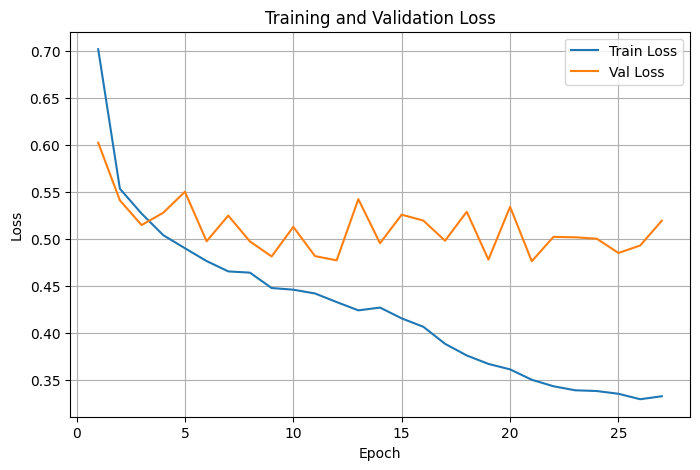

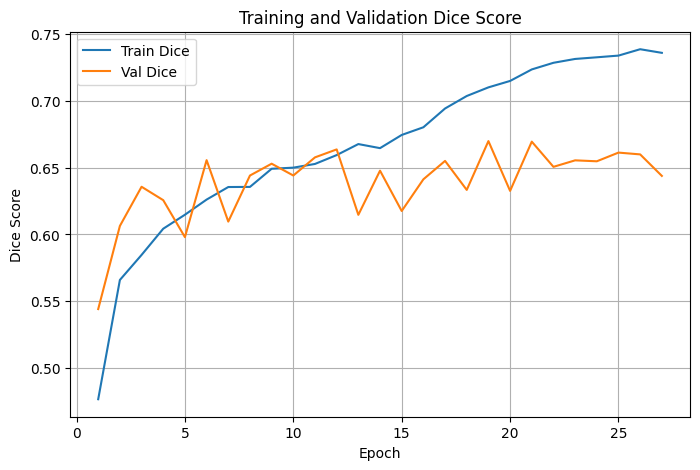

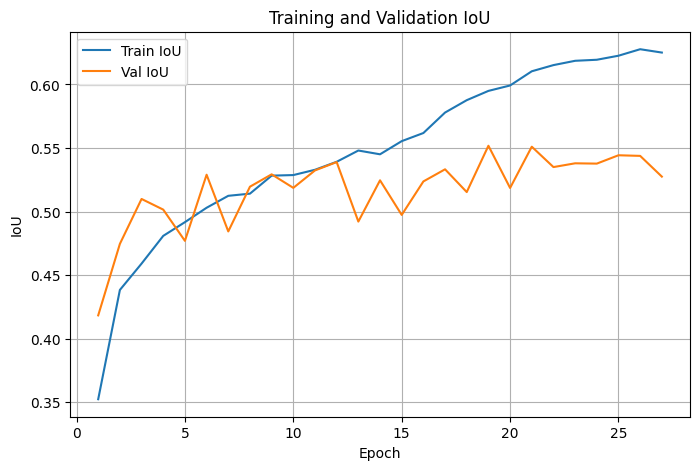

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_dice"], label="Train Dice")
plt.plot(history_df["epoch"], history_df["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Training and Validation Dice Score")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_iou"], label="Train IoU")
plt.plot(history_df["epoch"], history_df["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Training and Validation IoU")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
best_model = ResNet18UNetFreq(in_channels=4).to(CFG.device)
best_model.load_state_dict(torch.load(best_model_path, map_location=CFG.device))
best_model.eval()

print("Best ResNet18 FFT-Frequency Focal-Dice 352 model loaded.")

Best ResNet18 FFT-Frequency Focal-Dice 352 model loaded.


In [22]:
@torch.no_grad()
def evaluate_thresholds(model, loader, thresholds=np.arange(0.3, 0.71, 0.05)):
    model.eval()
    results = []

    for th in thresholds:
        dice_scores = []
        iou_scores = []
        mae_scores = []

        for images, masks in tqdm(loader, desc=f"Threshold {th:.2f}"):
            images = images.to(CFG.device)
            masks = masks.to(CFG.device)

            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs > th).float()

            tp = (preds * masks).sum(dim=(1, 2, 3))
            fp = (preds * (1 - masks)).sum(dim=(1, 2, 3))
            fn = ((1 - preds) * masks).sum(dim=(1, 2, 3))

            dice = (2 * tp + 1e-6) / (2 * tp + fp + fn + 1e-6)
            iou = (tp + 1e-6) / (tp + fp + fn + 1e-6)
            mae = torch.abs(probs - masks).mean(dim=(1, 2, 3))

            dice_scores.extend(dice.cpu().numpy())
            iou_scores.extend(iou.cpu().numpy())
            mae_scores.extend(mae.cpu().numpy())

        results.append({
            "threshold": th,
            "dice": np.mean(dice_scores),
            "iou": np.mean(iou_scores),
            "mae": np.mean(mae_scores)
        })

    return pd.DataFrame(results)


threshold_df = evaluate_thresholds(best_model, val_loader)
threshold_df

Threshold 0.30:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.35:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.40:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.45:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.50:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.55:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.60:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.65:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.70:   0%|          | 0/32 [00:00<?, ?it/s]

,threshold,dice,iou,mae
0,0.30,0.676609,0.557127,0.10736
1,0.35,0.674438,0.555395,0.10736
2,0.40,0.672230,0.553577,0.10736
3,0.45,0.669689,0.551356,0.10736
4,0.50,0.666373,0.548353,0.10736
5,0.55,0.661941,0.544323,0.10736
6,0.60,0.655999,0.538708,0.10736
7,0.65,0.647825,0.531099,0.10736
8,0.70,0.638652,0.522524,0.10736


In [23]:
best_threshold = threshold_df.loc[threshold_df["dice"].idxmax(), "threshold"]
print("Best threshold:", best_threshold)

Best threshold: 0.3


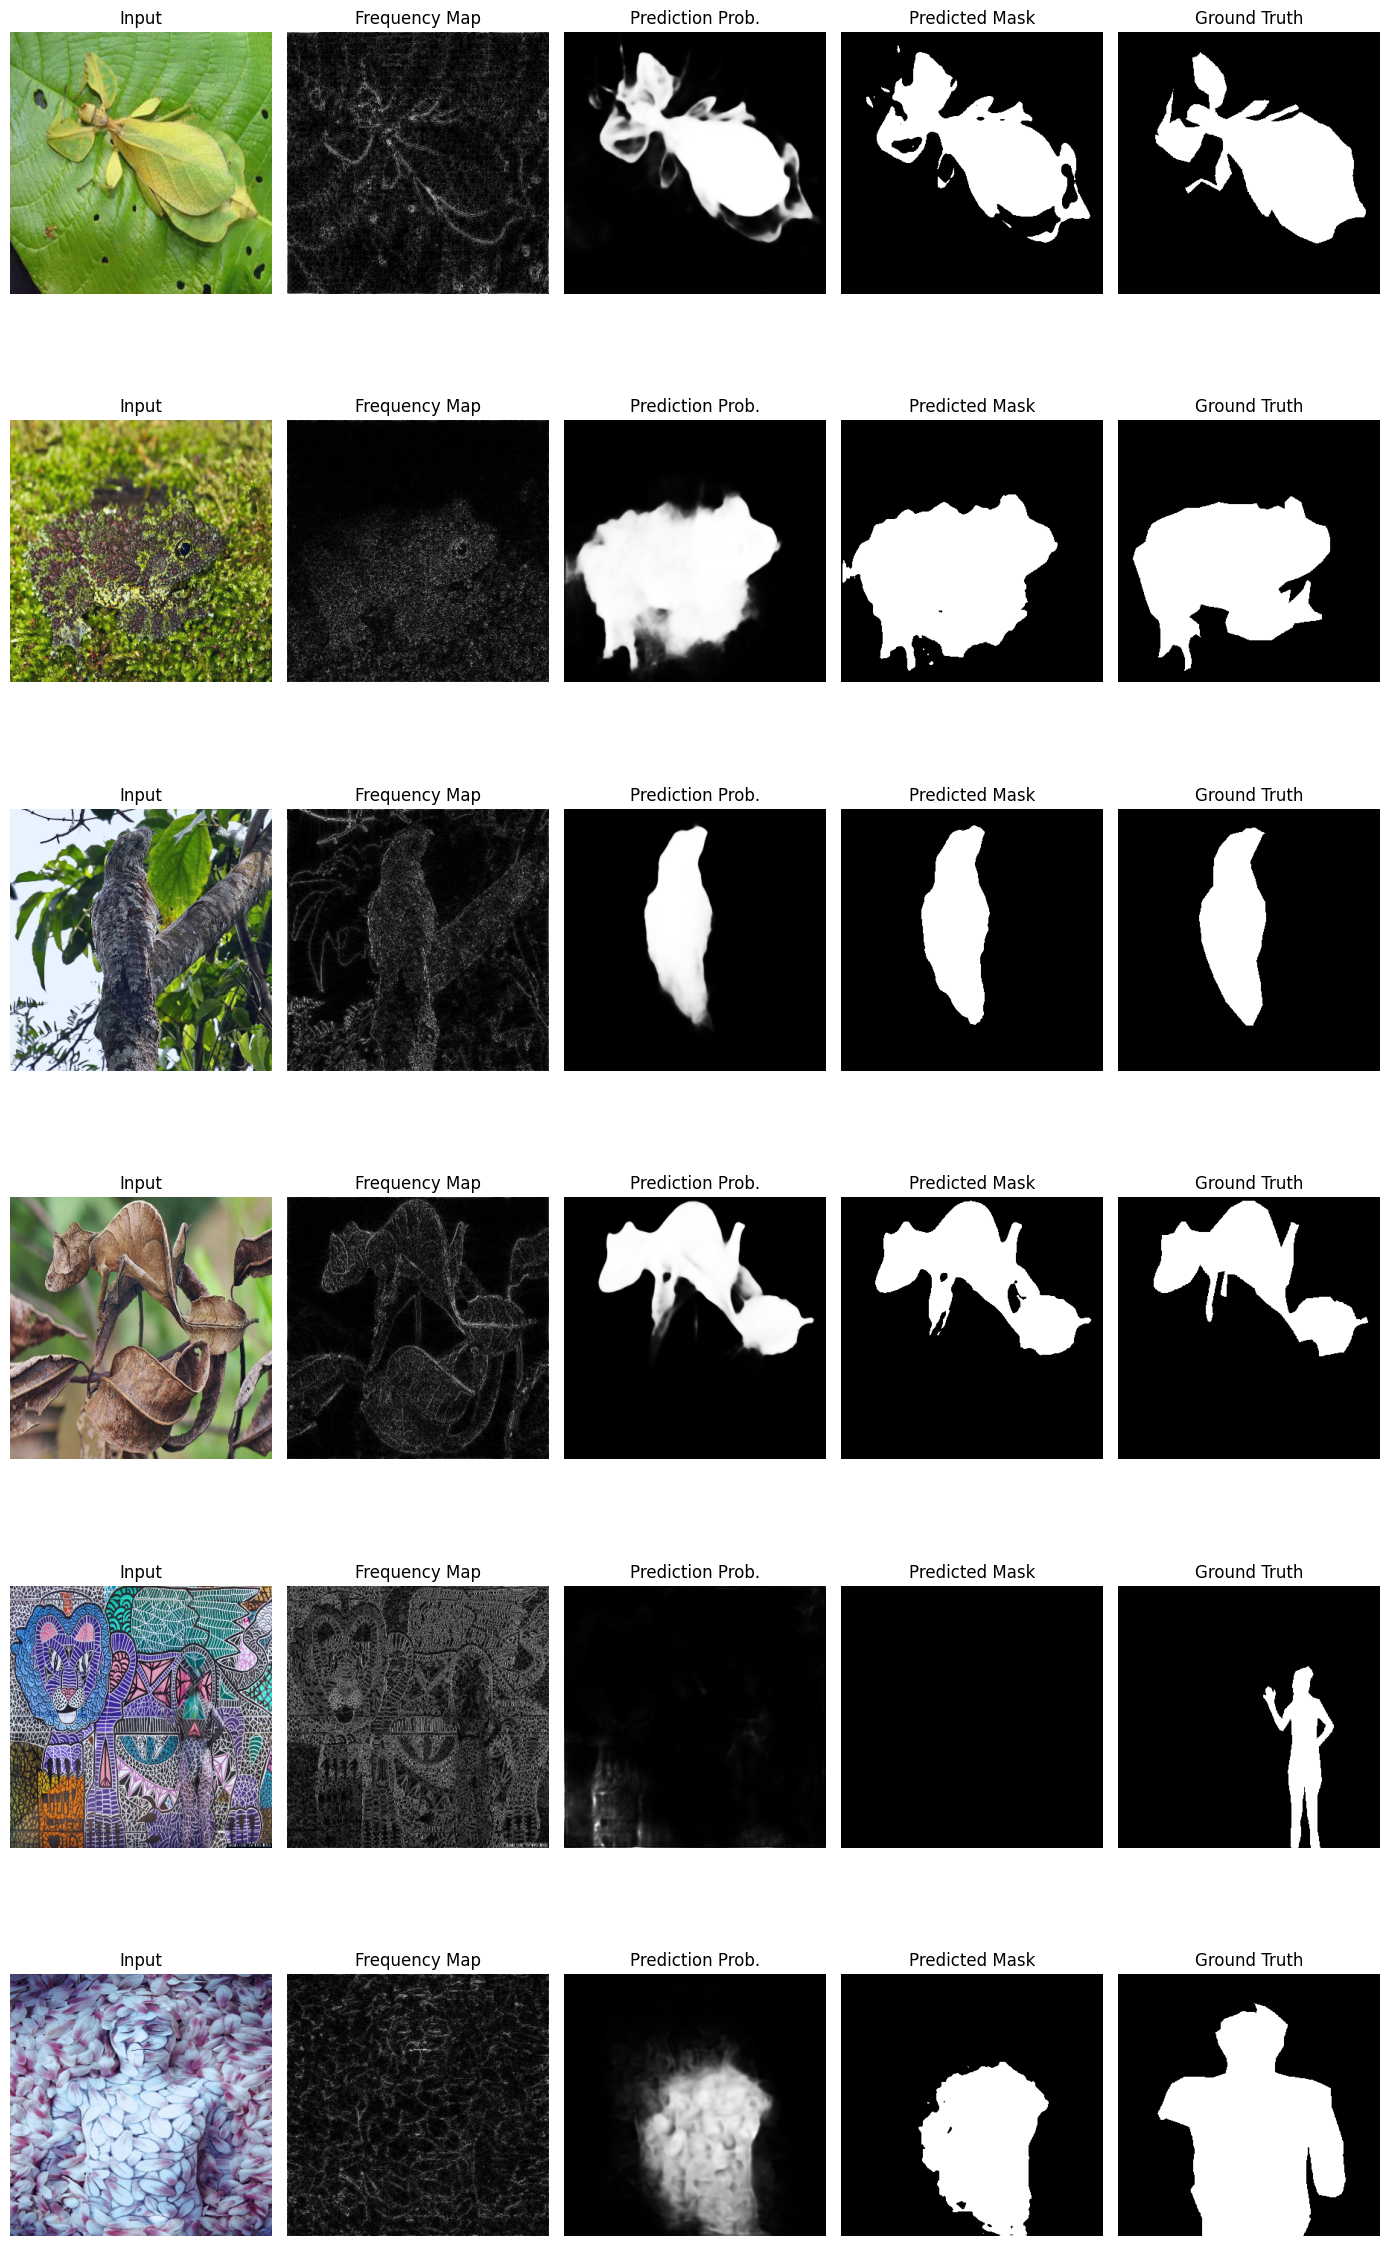

In [24]:
@torch.no_grad()
def visualize_predictions(model, dataset, n=5):
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    
    plt.figure(figsize=(14, 4 * len(indices)))
    
    for row, idx in enumerate(indices):
        image_tensor, mask_tensor = dataset[idx]
        
        input_tensor = image_tensor.unsqueeze(0).to(CFG.device)
        logits = model(input_tensor)
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred = (prob > best_threshold).astype(np.float32)
        
        img_np = image_tensor[:3].permute(1, 2, 0).cpu().numpy()
        freq_np = image_tensor[3].cpu().numpy()
        gt_np = mask_tensor[0].cpu().numpy()
        
        # Normalize image for visualization
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
        freq_vis = (freq_np - freq_np.min()) / (freq_np.max() - freq_np.min() + 1e-8)
        
        plt.subplot(len(indices), 5, row * 5 + 1)
        plt.imshow(img_np)
        plt.title("Input")
        plt.axis("off")
        
        plt.subplot(len(indices), 5, row * 5 + 2)
        plt.imshow(freq_vis, cmap="gray")
        plt.title("Frequency Map")
        plt.axis("off")
        
        plt.subplot(len(indices), 5, row * 5 + 3)
        plt.imshow(prob, cmap="gray")
        plt.title("Prediction Prob.")
        plt.axis("off")
        
        plt.subplot(len(indices), 5, row * 5 + 4)
        plt.imshow(pred, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")
        
        plt.subplot(len(indices), 5, row * 5 + 5)
        plt.imshow(gt_np, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

visualize_predictions(best_model, val_ds, n=6)

In [25]:
@torch.no_grad()
def evaluate_model(model, loader, threshold=0.5):
    model.eval()

    all_metrics = []

    for images, masks in tqdm(loader, desc="Final Evaluation"):
        images = images.to(CFG.device)
        masks = masks.to(CFG.device)

        logits = model(images)
        metrics = compute_metrics(logits, masks, threshold=threshold)
        all_metrics.append(metrics)

    df = pd.DataFrame(all_metrics)
    return df.mean().to_dict()

val_metrics = evaluate_model(best_model, val_loader, threshold=best_threshold)
test_metrics = evaluate_model(best_model, test_loader, threshold=best_threshold)

results_df = pd.DataFrame([
    {"split": "CAMO_Test_Validation", **val_metrics},
    {"split": "COD10K_Test", **test_metrics}
])

results_df.to_csv(
    os.path.join(CFG.save_dir, "final_val_test_metrics_resnet18_fft_freq_focal_dice_352_plateau.csv"),
    index=False
)

results_df

Final Evaluation:   0%|          | 0/32 [00:00<?, ?it/s]

Final Evaluation:   0%|          | 0/254 [00:00<?, ?it/s]

,split,dice,iou,mae
0,CAMO_Test_Validation,0.679973,0.560521,0.105603
1,COD10K_Test,0.633055,0.518136,0.053577


In [26]:
print("Saved files:")

for f in Path(CFG.save_dir).glob("*"):
    print(f)

Saved files:
/kaggle/working/cod_project_outputs/final_val_test_metrics_resnet18_fft_freq_focal_dice_352_plateau.csv
/kaggle/working/cod_project_outputs/training_history_resnet18_fft_freq_focal_dice_352_plateau.csv
/kaggle/working/cod_project_outputs/best_resnet18_fft_freq_focal_dice_352_plateau.pth


In [27]:
def mae_score(pred, gt):
    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)
    return np.mean(np.abs(pred - gt))


def f_measure_score(pred, gt, beta2=0.3, threshold=0.5, eps=1e-8):
    pred_bin = (pred >= threshold).astype(np.float32)
    gt = gt.astype(np.float32)

    tp = np.sum(pred_bin * gt)
    precision = tp / (np.sum(pred_bin) + eps)
    recall = tp / (np.sum(gt) + eps)

    f_beta = (1 + beta2) * precision * recall / (
        beta2 * precision + recall + eps
    )
    return float(f_beta)


def max_f_measure_score(pred, gt, beta2=0.3, thresholds=np.linspace(0.0, 1.0, 256)):
    scores = [
        f_measure_score(pred, gt, beta2=beta2, threshold=t)
        for t in thresholds
    ]
    return float(np.max(scores))


def enhanced_alignment_measure(pred, gt, eps=1e-8):
    """
    Simplified E-measure.
    pred: probability map [0,1]
    gt: binary mask [0,1]
    """
    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)

    if np.sum(gt) == 0:
        return 1.0 - np.mean(pred)

    if np.sum(gt) == gt.size:
        return np.mean(pred)

    pred_mean = np.mean(pred)
    gt_mean = np.mean(gt)

    align_matrix = 2 * (pred - pred_mean) * (gt - gt_mean)
    align_matrix = align_matrix / (
        (pred - pred_mean) ** 2 + (gt - gt_mean) ** 2 + eps
    )

    enhanced = ((align_matrix + 1) ** 2) / 4
    return float(np.mean(enhanced))


def object_score(pred, gt, eps=1e-8):
    fg = pred[gt == 1]
    bg = pred[gt == 0]

    if len(fg) == 0:
        o_fg = 0.0
    else:
        mu = np.mean(fg)
        sigma = np.std(fg)
        o_fg = 2 * mu / (mu ** 2 + 1 + sigma + eps)

    if len(bg) == 0:
        o_bg = 0.0
    else:
        bg = 1 - bg
        mu = np.mean(bg)
        sigma = np.std(bg)
        o_bg = 2 * mu / (mu ** 2 + 1 + sigma + eps)

    u = np.mean(gt)
    return float(u * o_fg + (1 - u) * o_bg)


def ssim_region(pred, gt, eps=1e-8):
    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)

    x = np.mean(pred)
    y = np.mean(gt)

    sigma_x = np.var(pred)
    sigma_y = np.var(gt)
    sigma_xy = np.mean((pred - x) * (gt - y))

    alpha = 4 * x * y * sigma_xy
    beta = (x ** 2 + y ** 2) * (sigma_x + sigma_y)

    if beta == 0:
        return 1.0 if alpha == 0 else 0.0

    return float(alpha / (beta + eps))


def divide_prediction_gt(pred, gt):
    h, w = gt.shape

    if np.sum(gt) == 0:
        cx, cy = w // 2, h // 2
    else:
        ys, xs = np.where(gt == 1)
        cx = int(np.mean(xs))
        cy = int(np.mean(ys))

    cx = np.clip(cx, 1, w - 1)
    cy = np.clip(cy, 1, h - 1)

    pred_regions = [
        pred[:cy, :cx],
        pred[:cy, cx:],
        pred[cy:, :cx],
        pred[cy:, cx:]
    ]

    gt_regions = [
        gt[:cy, :cx],
        gt[:cy, cx:],
        gt[cy:, :cx],
        gt[cy:, cx:]
    ]

    weights = [
        (cx * cy) / (h * w),
        ((w - cx) * cy) / (h * w),
        (cx * (h - cy)) / (h * w),
        ((w - cx) * (h - cy)) / (h * w)
    ]

    return pred_regions, gt_regions, weights


def region_score(pred, gt):
    pred_regions, gt_regions, weights = divide_prediction_gt(pred, gt)

    score = 0.0
    for p, g, w in zip(pred_regions, gt_regions, weights):
        if p.size == 0 or g.size == 0:
            continue
        score += w * ssim_region(p, g)

    return float(score)


def s_measure_score(pred, gt, alpha=0.5):
    """
    Simplified S-measure.
    """
    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)

    if np.sum(gt) == 0:
        return 1.0 - np.mean(pred)

    if np.sum(gt) == gt.size:
        return np.mean(pred)

    s_object = object_score(pred, gt)
    s_region = region_score(pred, gt)

    return float(alpha * s_object + (1 - alpha) * s_region)


@torch.no_grad()
def evaluate_cod_metrics(model, loader, threshold=0.5):
    model.eval()

    dice_list = []
    iou_list = []
    mae_list = []
    f_list = []
    max_f_list = []
    s_list = []
    e_list = []

    for images, masks in tqdm(loader, desc="Evaluating COD metrics"):
        images = images.to(CFG.device)
        masks = masks.to(CFG.device)

        logits = model(images)
        probs = torch.sigmoid(logits)

        probs_np = probs.detach().cpu().numpy()
        masks_np = masks.detach().cpu().numpy()

        for i in range(probs_np.shape[0]):
            pred = probs_np[i, 0]
            gt = masks_np[i, 0]

            pred_bin = (pred >= threshold).astype(np.float32)

            tp = np.sum(pred_bin * gt)
            fp = np.sum(pred_bin * (1 - gt))
            fn = np.sum((1 - pred_bin) * gt)

            dice = (2 * tp + 1e-8) / (2 * tp + fp + fn + 1e-8)
            iou = (tp + 1e-8) / (tp + fp + fn + 1e-8)

            dice_list.append(dice)
            iou_list.append(iou)
            mae_list.append(mae_score(pred, gt))
            f_list.append(f_measure_score(pred, gt, threshold=threshold))
            max_f_list.append(max_f_measure_score(pred, gt))
            s_list.append(s_measure_score(pred, gt))
            e_list.append(enhanced_alignment_measure(pred, gt))

    return {
        "Dice": np.mean(dice_list),
        "IoU": np.mean(iou_list),
        "MAE": np.mean(mae_list),
        "F_measure": np.mean(f_list),
        "Max_F_measure": np.mean(max_f_list),
        "S_measure": np.mean(s_list),
        "E_measure": np.mean(e_list)
    }

In [28]:
val_cod_metrics = evaluate_cod_metrics(
    best_model,
    val_loader,
    threshold=best_threshold
)

test_cod_metrics = evaluate_cod_metrics(
    best_model,
    test_loader,
    threshold=best_threshold
)

cod_metrics_df = pd.DataFrame([
    {"split": "CAMO_Test_Validation", **val_cod_metrics},
    {"split": "COD10K_Test", **test_cod_metrics}
])

cod_metrics_df.to_csv(
    os.path.join(CFG.save_dir, "final_cod_metrics_resnet18_fft_freq_focal_dice_352_plateau.csv"),
    index=False
)

cod_metrics_df

Evaluating COD metrics:   0%|          | 0/32 [00:00<?, ?it/s]

Evaluating COD metrics:   0%|          | 0/254 [00:00<?, ?it/s]

,split,Dice,IoU,MAE,F_measure,Max_F_measure,S_measure,E_measure
0,CAMO_Test_Validation,0.676609,0.557127,0.107360,0.689547,0.770921,0.746818,0.795561
1,COD10K_Test,0.632411,0.517408,0.053644,0.630109,0.719956,0.751381,0.826767


In [29]:
class FrequencyGuidedFusionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.freq_attention = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 1, kernel_size=1),
            nn.Sigmoid()
        )

        self.segmentor = ResNet18UNetFreq(in_channels=4)

    def forward(self, x):
        rgb = x[:, :3, :, :]
        freq = x[:, 3:4, :, :]

        attention = self.freq_attention(freq)

        enhanced_rgb = rgb * (1.0 + attention)

        fused_input = torch.cat([enhanced_rgb, freq], dim=1)

        return self.segmentor(fused_input)

In [30]:
fusion_model = FrequencyGuidedFusionUNet().to(CFG.device)

fusion_optimizer = torch.optim.AdamW(
    fusion_model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay
)

fusion_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    fusion_optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=CFG.min_lr
)

fusion_scaler = torch.cuda.amp.GradScaler(enabled=CFG.use_amp)

fusion_history = []

fusion_best_val_dice = -1
fusion_best_model_path = os.path.join(
    CFG.save_dir,
    "best_freq_guided_fusion_unet_resnet18_fft_focal_dice_352.pth"
)

fusion_patience_counter = 0

for epoch in range(1, CFG.epochs + 1):
    train_metrics = train_one_epoch(
        fusion_model,
        train_loader,
        fusion_optimizer,
        fusion_scaler,
        epoch
    )

    val_metrics = validate_one_epoch(
        fusion_model,
        val_loader,
        epoch
    )

    fusion_scheduler.step(val_metrics["loss"])

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "train_mae": train_metrics["mae"],
        "val_loss": val_metrics["loss"],
        "val_dice": val_metrics["dice"],
        "val_iou": val_metrics["iou"],
        "val_mae": val_metrics["mae"],
        "lr": fusion_optimizer.param_groups[0]["lr"]
    }

    fusion_history.append(row)
    print(row)

    if val_metrics["dice"] > fusion_best_val_dice:
        fusion_best_val_dice = val_metrics["dice"]
        torch.save(fusion_model.state_dict(), fusion_best_model_path)
        fusion_patience_counter = 0
        print(
            f"Best fusion model saved: {fusion_best_model_path} | "
            f"Best val dice: {fusion_best_val_dice:.4f}"
        )
    else:
        fusion_patience_counter += 1
        print(f"No improvement. Patience: {fusion_patience_counter}/{CFG.patience}")

    if fusion_patience_counter >= CFG.patience:
        print("Early stopping triggered for fusion model.")
        break

fusion_history_df = pd.DataFrame(fusion_history)

fusion_history_df.to_csv(
    os.path.join(
        CFG.save_dir,
        "training_history_freq_guided_fusion_unet_resnet18_fft_focal_dice_352.csv"
    ),
    index=False
)

fusion_history_df

/tmp/ipykernel_57/136455832.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  fusion_scaler = torch.cuda.amp.GradScaler(enabled=CFG.use_amp)


Train Epoch 1:   0%|          | 0/505 [00:00<?, ?it/s]

/tmp/ipykernel_57/4177375609.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.use_amp):


Val Epoch 1:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.6782453493316575, 'train_dice': 0.4882056668548301, 'train_iou': 0.36201247979361234, 'train_mae': 0.18216223685753227, 'val_loss': 0.5559540186077356, 'val_dice': 0.589536041021347, 'val_iou': 0.45262991869822145, 'val_mae': 0.1451450469903648, 'lr': 0.0001}
Best fusion model saved: /kaggle/working/cod_project_outputs/best_freq_guided_fusion_unet_resnet18_fft_focal_dice_352.pth | Best val dice: 0.5895


...

{'epoch': 29, 'train_loss': 0.3364952892655193, 'train_dice': 0.7337063562161852, 'train_iou': 0.6218253061322883, 'train_mae': 0.04610842304802177, 'val_loss': 0.5145846987143159, 'val_dice': 0.638152732513845, 'val_iou': 0.523817605804652, 'val_mae': 0.10691142803989351, 'lr': 3.125e-06}
No improvement. Patience: 5/8


Train Epoch 30:   0%|          | 0/505 [00:00<?, ?it/s]

Val Epoch 30:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 30, 'train_loss': 0.3340311863339773, 'train_dice': 0.7357934942339907, 'train_iou': 0.6245015300146424, 'train_mae': 0.04573694849663442, 'val_loss': 0.5148017508909106, 'val_dice': 0.6401178892701864, 'val_iou': 0.5246647312305868, 'val_mae': 0.10673245694488287, 'lr': 1.5625e-06}
No improvement. Patience: 6/8


,epoch,train_loss,train_dice,train_iou,train_mae,val_loss,val_dice,val_iou,val_mae,lr
0,1,0.678245,0.488206,0.362012,0.182162,0.555954,0.589536,0.452630,0.145145,0.000100
1,2,0.551436,0.566800,0.440222,0.088861,0.552520,0.597031,0.469063,0.129028,0.000100
2,3,0.526252,0.588100,0.463096,0.083315,0.563375,0.590350,0.465053,0.127894,0.000100
3,4,0.504973,0.603873,0.479651,0.078757,0.517477,0.633323,0.500325,0.125025,0.000100
4,5,0.492534,0.613715,0.490025,0.075963,0.513767,0.639637,0.509497,0.124058,0.000100
5,6,0.482388,0.622391,0.499174,0.073007,0.544350,0.615321,0.490810,0.122226,0.000100
6,7,0.468444,0.633174,0.511073,0.070418,0.548931,0.609476,0.489176,0.117393,0.000100
7,8,0.463311,0.637326,0.515059,0.069678,0.540542,0.618775,0.494503,0.120506,0.000100
8,9,0.457414,0.641218,0.519816,0.068769,0.581630,0.581086,0.465526,0.119065,0.000050
9,10,0.424710,0.666228,0.546858,0.061831,0.491748,0.646489,0.525523,0.114937,0.000050


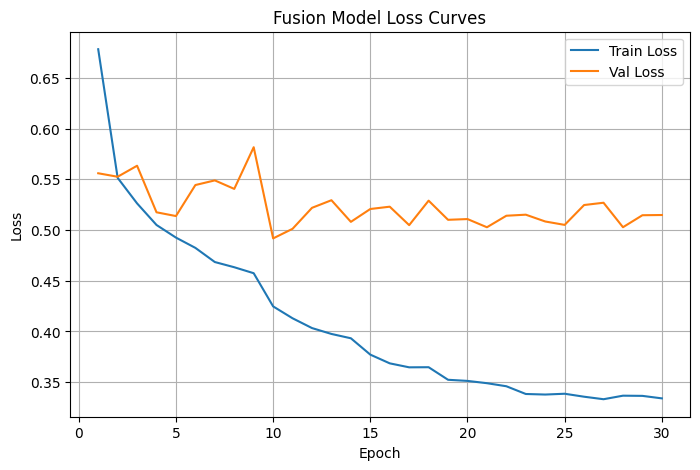

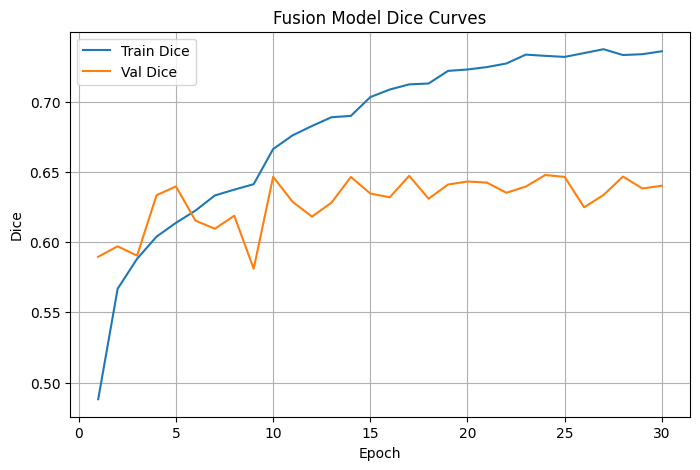

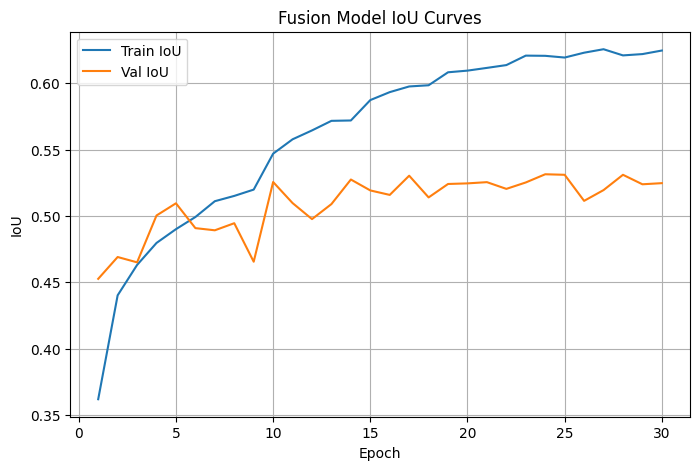

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(fusion_history_df["epoch"], fusion_history_df["train_loss"], label="Train Loss")
plt.plot(fusion_history_df["epoch"], fusion_history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fusion Model Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(fusion_history_df["epoch"], fusion_history_df["train_dice"], label="Train Dice")
plt.plot(fusion_history_df["epoch"], fusion_history_df["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Fusion Model Dice Curves")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(fusion_history_df["epoch"], fusion_history_df["train_iou"], label="Train IoU")
plt.plot(fusion_history_df["epoch"], fusion_history_df["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Fusion Model IoU Curves")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
fusion_best_model = FrequencyGuidedFusionUNet().to(CFG.device)

fusion_best_model.load_state_dict(
    torch.load(fusion_best_model_path, map_location=CFG.device)
)

fusion_best_model.eval()

print("Best Frequency-Guided Spatial-Frequency Fusion U-Net model loaded.")

Best Frequency-Guided Spatial-Frequency Fusion U-Net model loaded.


In [33]:
fusion_threshold_df = evaluate_thresholds(fusion_best_model, val_loader)

fusion_threshold_df

Threshold 0.30:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.35:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.40:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.45:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.50:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.55:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.60:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.65:   0%|          | 0/32 [00:00<?, ?it/s]

Threshold 0.70:   0%|          | 0/32 [00:00<?, ?it/s]

,threshold,dice,iou,mae
0,0.30,0.656975,0.539367,0.109487
1,0.35,0.654741,0.537695,0.109487
2,0.40,0.652095,0.535570,0.109487
3,0.45,0.649058,0.533039,0.109487
4,0.50,0.645704,0.530212,0.109487
5,0.55,0.641877,0.526947,0.109487
6,0.60,0.637580,0.523413,0.109487
7,0.65,0.632135,0.518985,0.109487
8,0.70,0.625302,0.513273,0.109487


In [34]:
fusion_best_threshold = fusion_threshold_df.loc[
    fusion_threshold_df["dice"].idxmax(),
    "threshold"
]

print("Best fusion threshold:", fusion_best_threshold)

Best fusion threshold: 0.3


In [35]:
fusion_val_metrics = evaluate_model(
    fusion_best_model,
    val_loader,
    threshold=fusion_best_threshold
)

fusion_test_metrics = evaluate_model(
    fusion_best_model,
    test_loader,
    threshold=fusion_best_threshold
)

fusion_results_df = pd.DataFrame([
    {"split": "CAMO_Test_Validation", **fusion_val_metrics},
    {"split": "COD10K_Test", **fusion_test_metrics}
])

fusion_results_df.to_csv(
    os.path.join(
        CFG.save_dir,
        "final_val_test_metrics_freq_guided_fusion_unet_resnet18_fft_focal_dice_352.csv"
    ),
    index=False
)

fusion_results_df

Final Evaluation:   0%|          | 0/32 [00:00<?, ?it/s]

Final Evaluation:   0%|          | 0/254 [00:00<?, ?it/s]

,split,dice,iou,mae
0,CAMO_Test_Validation,0.659135,0.540774,0.107885
1,COD10K_Test,0.649524,0.534135,0.051006


In [36]:
fusion_val_cod_metrics = evaluate_cod_metrics(
    fusion_best_model,
    val_loader,
    threshold=fusion_best_threshold
)

fusion_test_cod_metrics = evaluate_cod_metrics(
    fusion_best_model,
    test_loader,
    threshold=fusion_best_threshold
)

fusion_cod_metrics_df = pd.DataFrame([
    {"split": "CAMO_Test_Validation", **fusion_val_cod_metrics},
    {"split": "COD10K_Test", **fusion_test_cod_metrics}
])

fusion_cod_metrics_df.to_csv(
    os.path.join(
        CFG.save_dir,
        "final_cod_metrics_freq_guided_fusion_unet_resnet18_fft_focal_dice_352.csv"
    ),
    index=False
)

fusion_cod_metrics_df

Evaluating COD metrics:   0%|          | 0/32 [00:00<?, ?it/s]

Evaluating COD metrics:   0%|          | 0/254 [00:00<?, ?it/s]

,split,Dice,IoU,MAE,F_measure,Max_F_measure,S_measure,E_measure
0,CAMO_Test_Validation,0.656975,0.539367,0.109487,0.671827,0.766105,0.731600,0.785434
1,COD10K_Test,0.648908,0.533432,0.051067,0.645543,0.731253,0.760195,0.838191
